# NFDI4Earth

# Project: NFDI4Earth Hackathon 11.2025

## Goal: Explore data and run example machine learning analysis

```
Author: Daria Pankova
Data: 20.08.20205
Last update: 27.09.2025

This code is based on the code of Josepha Schiller (for R), which is
based on Ryo 2022:
https://github.com/masahiroryo/2022_IML_Agriculture/tree/main
(https://github.com/masahiroryo/2022_IML_Agriculture/tree/main)
```

### 1. Load libraries

Throughout this script we will rely on a number of packages from the R ecosystem. These packages provide helper functions for data manipulation,
plotting, and machine learning. Below we load them at once so they are available later. You do not need to understand every package now; inline
comments clarify each library’s role.

In [1]:
# Core data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Combine multiple plots (equivalent to patchwork)
from matplotlib import gridspec
import matplotlib.gridspec as gridspec

# Data reshaping (equivalent to reshape2)
from pandas import melt, pivot_table

# Correlation plots (equivalent to corrplot)
import scipy.stats as stats

# Multicollinearity diagnostics (equivalent to car)
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# Machine Learning specific libraries
from sklearn import datasets, model_selection, preprocessing, metrics
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.svm import SVR, SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

from sklearn.inspection import PartialDependenceDisplay

# Variable importance plots
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings('ignore')

In [2]:
#
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [3]:
#
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

### 2. Load data

In this section we read the dataset. The Air Quality Index (AQI) dataset is stored as a comma‑separated values (CSV) file. You will need to adapt
the path to point to the directory where your copy of the dataset resides.

In [8]:
# Read the dataset
from google.colab import files
uploaded = files.upload()
dta = pd.read_csv("aqi_dataset_positive.csv")

# Display the first few rows of the dataset
# Look at information about the data structure. First, look at the top rows.
print(dta.head())

Saving aqi_dataset_positive.csv to aqi_dataset_positive (1).csv
   temperature  humidity  wind_speed  traffic_density  industrial_activity  \
0        28.48     70.89        7.49             10.0                83.67   
1        24.03     65.24       14.13              9.0                49.93   
2        29.53     55.93       15.29              7.0                82.52   
3        35.66     74.91        9.91              3.0                31.72   
4        23.36     60.99        8.38              3.0                45.26   

      AQI  
0  149.46  
1  164.90  
2  155.39  
3  105.21  
4  118.21  


In [9]:
# Display the structure of the dataset
dta.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14235 entries, 0 to 14234
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   temperature          13952 non-null  float64
 1   humidity             13951 non-null  float64
 2   wind_speed           13955 non-null  float64
 3   traffic_density      14093 non-null  float64
 4   industrial_activity  14093 non-null  float64
 5   AQI                  14235 non-null  float64
dtypes: float64(6)
memory usage: 667.4 KB


### 3. Data exploration

We start with the exploratory data analysis (EDA) following the DIG framework.
This includes getting an idea about what data is included in our dataset.
1. Describe the dataset
2. Introspection: brainstorm research questions
3. Goal setting: define a research question

### 3.1 Describe the dataset

What are the column variable names?

In [10]:
n_columns = dta.shape[1]
column_names = dta.columns.tolist()

In [11]:
column_names

['temperature',
 'humidity',
 'wind_speed',
 'traffic_density',
 'industrial_activity',
 'AQI']

### How many entries exist?

In [12]:
n_rows = dta.shape[0]
n_rows

14235

We can look at the top rows.

In [13]:
dta.head()  # display the first rows to get a sense of the data

,temperature,humidity,wind_speed,traffic_density,industrial_activity,AQI
0,28.48,70.89,7.49,10.0,83.67,149.46
1,24.03,65.24,14.13,9.0,49.93,164.90
2,29.53,55.93,15.29,7.0,82.52,155.39
3,35.66,74.91,9.91,3.0,31.72,105.21
4,23.36,60.99,8.38,3.0,45.26,118.21


We can also look at the summary statistics for this dataset. What to look for? Missing values, realistic ranges in variables.

In [14]:
# Summary statistics
dta.describe(include='all')

,temperature,humidity,wind_speed,traffic_density,industrial_activity,AQI
count,13952.000000,13951.000000,13955.000000,14093.000000,14093.000000,14235.000000
mean,25.013971,60.048586,9.995336,5.565529,50.275211,122.226988
std,7.016355,14.891584,3.018661,2.892785,20.078260,56.969442
min,0.000000,2.150000,0.000000,1.000000,0.000000,0.000000
25%,20.330000,49.800000,7.930000,3.000000,36.550000,82.915000
50%,25.000000,60.120000,9.990000,6.000000,50.440000,121.330000
75%,29.710000,70.165000,12.060000,8.000000,64.020000,159.290000
max,52.480000,127.190000,21.180000,10.000000,124.910000,531.030000


#### How is the data quality?

Missing values per column:

In [15]:
# Check for NA values in each column
na_counts = dta.isna().sum()
na_counts

,0
temperature,283
humidity,284
wind_speed,280
traffic_density,142
industrial_activity,142
AQI,0


Data types for each column

In [16]:
dta.dtypes  # returns the class (e.g., numeric, factor) of each column

,0
temperature,float64
humidity,float64
wind_speed,float64
traffic_density,float64
industrial_activity,float64
AQI,float64


**Open question 1** Is it possible to have negative wind speed, negative industrial activities, and negative air
quality?
**Open question 2** Is it possible to have humanity higher than 100?


How much percent of the data are missing?

In [17]:
# Count total rows
n = len(dta)  # total number of rows in the dataset
col_missing_pct = (dta.isna().sum() / n) * 100  # compute missing values as percentage of total rows
col_missing_pct  # print the percentages for each colu

,0
temperature,1.988058
humidity,1.995083
wind_speed,1.966983
traffic_density,0.997541
industrial_activity,0.997541
AQI,0.000000


It is important to keep in mind that for the machine learning analysis, we cannot use data rows that have NA values. That’s why we can check how
many rows remain after removing NA values.

In [18]:
dta.dropna().head()  # remove any rows containing at least one missing value

,temperature,humidity,wind_speed,traffic_density,industrial_activity,AQI
0,28.48,70.89,7.49,10.0,83.67,149.46
1,24.03,65.24,14.13,9.0,49.93,164.90
2,29.53,55.93,15.29,7.0,82.52,155.39
3,35.66,74.91,9.91,3.0,31.72,105.21
4,23.36,60.99,8.38,3.0,45.26,118.21


Check for duplicates.

In [19]:
# Check for duplicated rows
duplicated_count = dta.duplicated().sum()
duplicated_count

np.int64(0)

In [20]:
# View duplicated rows (if any)
if duplicated_count > 0:
    print("\nDuplicated rows:")
    print(dta[dta.duplicated(keep=False)])

### Visual eploration

Histograms allow to see the range, distribution, and outliers.


Creating histograms for 6 numeric columns...


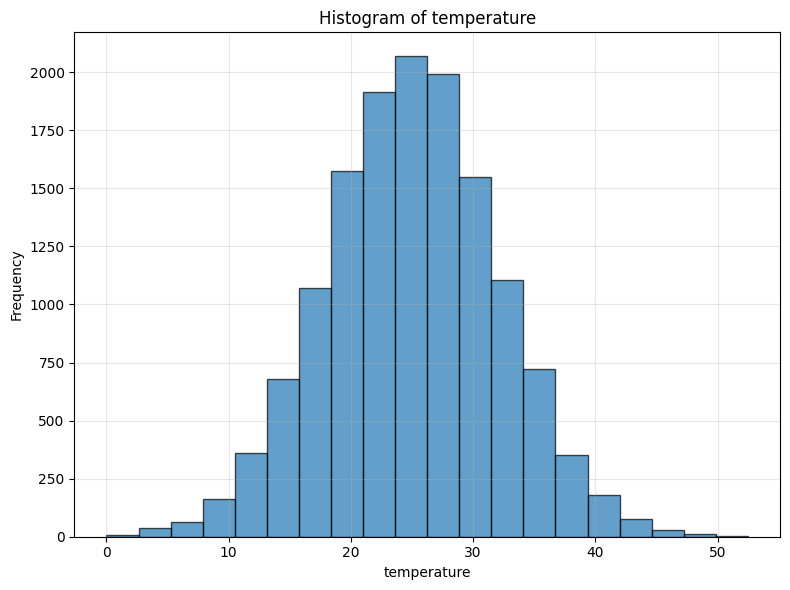

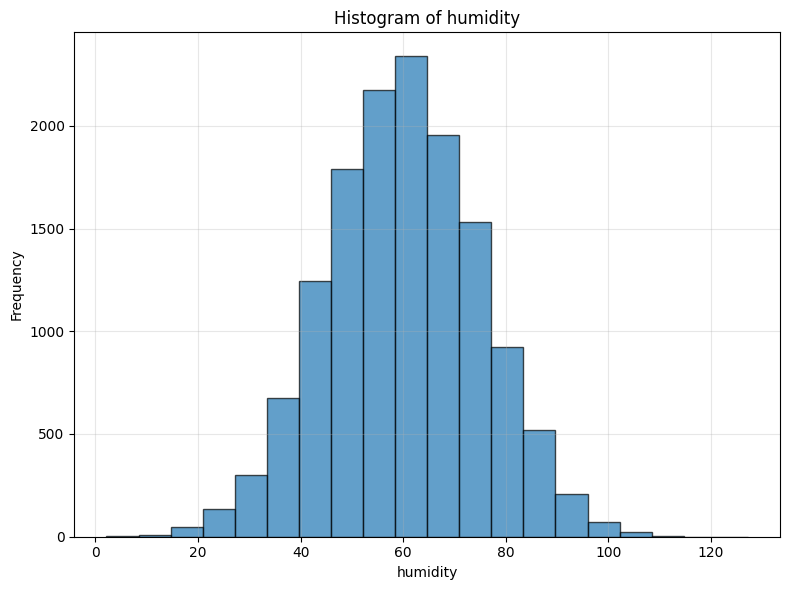

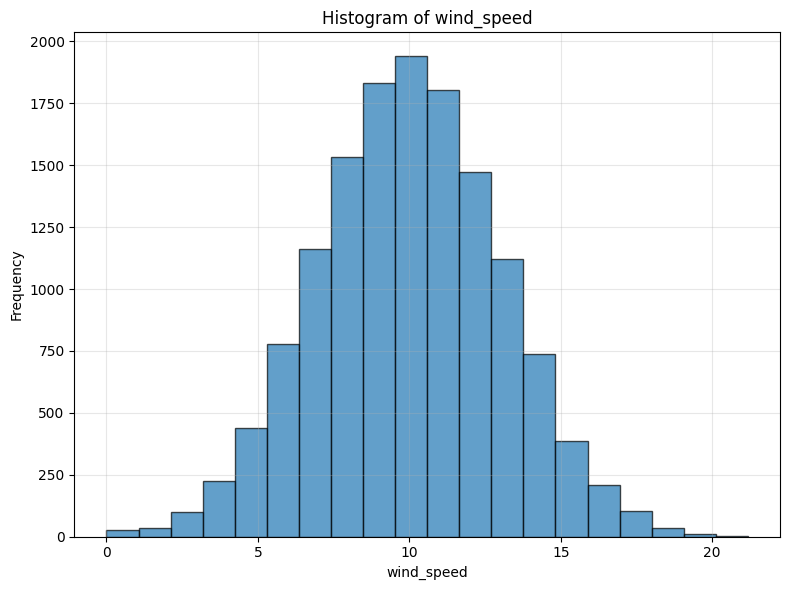

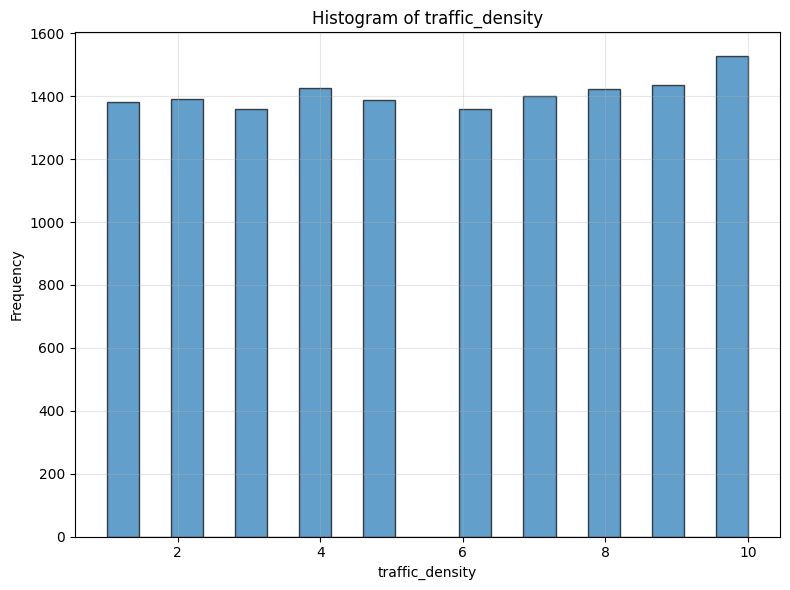

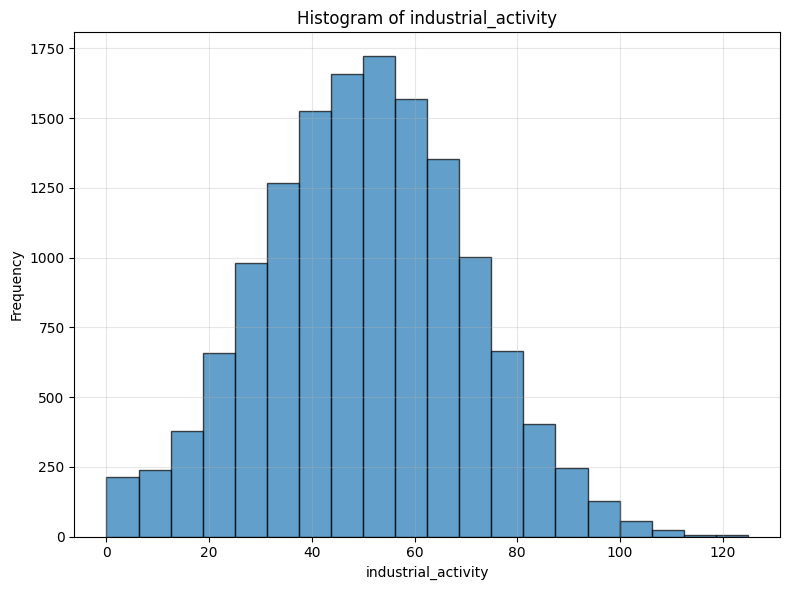

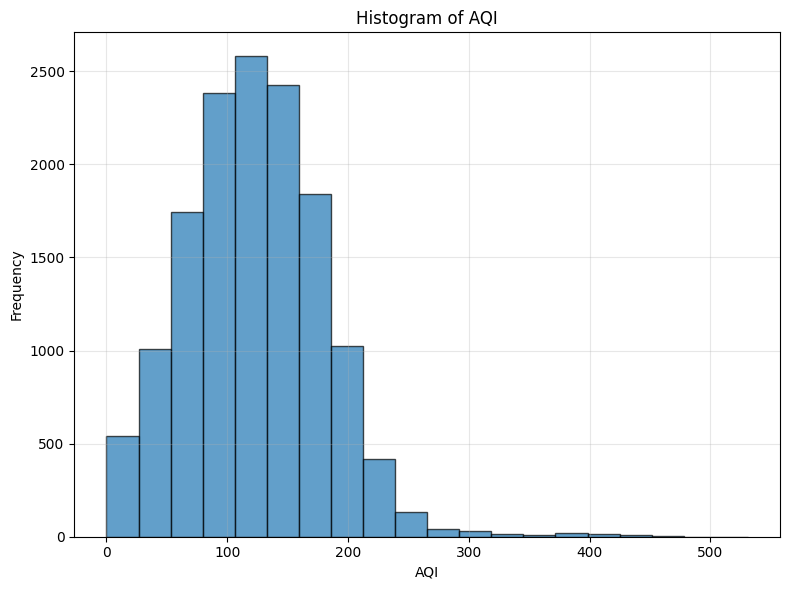

In [21]:
bins_n = 20 #choose bins number in histograms
df = dta.copy()
numeric_columns = df.select_dtypes(include=[np.number]).columns

print(f"\nCreating histograms for {len(numeric_columns)} numeric columns...")

for col in numeric_columns:
    plt.figure(figsize=(8, 6))
    plt.hist(df[col].dropna(), bins=bins_n, alpha=0.7, edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

Box plots are nice because they give information about: Min, Q1, Median, Q3, Max. Outliers can be recognized beyond the whiskers.

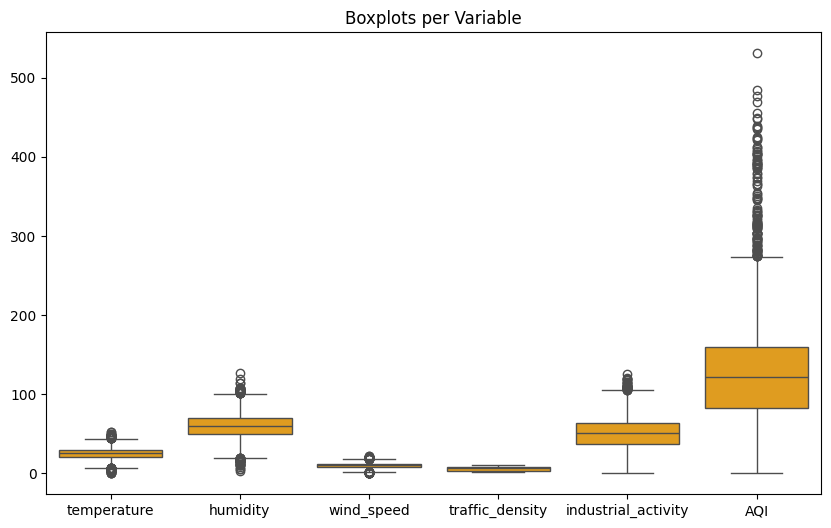

In [22]:
df_long = df.select_dtypes(include=[np.number]).melt(var_name="variable", value_name="value")  # reshape into two columns: variable and value
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_long, x="variable", y="value", color="orange")  # boxplots summarise distribution for each variable
plt.title("Boxplots per Variable")
plt.xlabel(None)
plt.ylabel(None)
plt.show()

A very nice way to combine information from boxplots and histograms are violinplots.

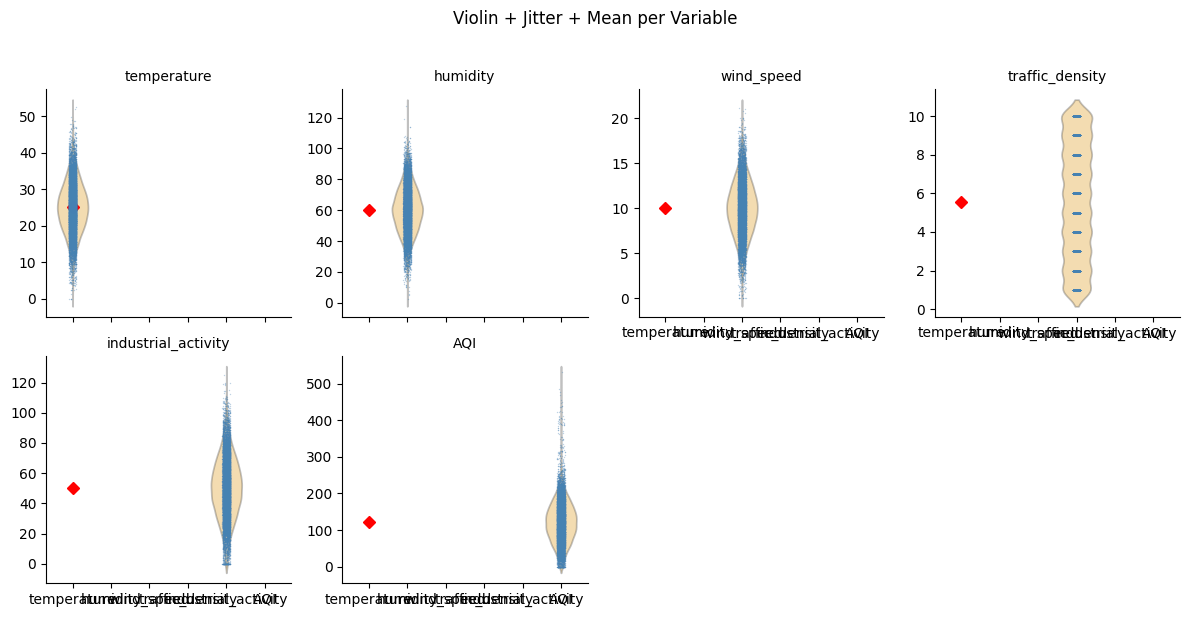

In [23]:
g = sns.FacetGrid(df_long, col="variable", col_wrap=4, sharey=False)  # facet each variable to its own panel
g = g.map_dataframe(sns.violinplot, x="variable", y="value", color="orange", alpha=0.35, inner=None)
g = g.map_dataframe(sns.stripplot, x="variable", y="value", color="steelblue", alpha=0.35, size=1, jitter=True)

for ax, var in zip(g.axes.flat, df_long['variable'].unique()):
    mean_val = df_long[df_long['variable'] == var]['value'].mean()
    ax.plot(0, mean_val, marker='D', markersize=6, color='red', markeredgecolor='red')

g.set_titles("{col_name}")
g.set_axis_labels("", "")
g.fig.suptitle("Violin + Jitter + Mean per Variable", y=1.02)
plt.tight_layout()
plt.show()

### 3.2 Introspection

**What research questions could possibly be answered?**

After exploring the dataset and understanding its structure, the next step is to formulate potential research questions. The research question
guides the direction of the analysis and help determine which variables are most relevant.

When defining the research question, one must ensure that the variables used for prediction are complete (no missing values). Why? Machine
learning models cannot handle missing values directly. Variables with a large proportion of missing data are not suitable for use as predictors
unless imputation or other strategies are applied.

**Example research question:** Predicting air quality Index based on the given variables

Now that we have a research question in mind, we can do more directed data exploration. Bivariate scatter plots with target variable “AQI” allow to
detect links between target and predictor variables.

### Example 1: Prediciting Air Quality Indeix

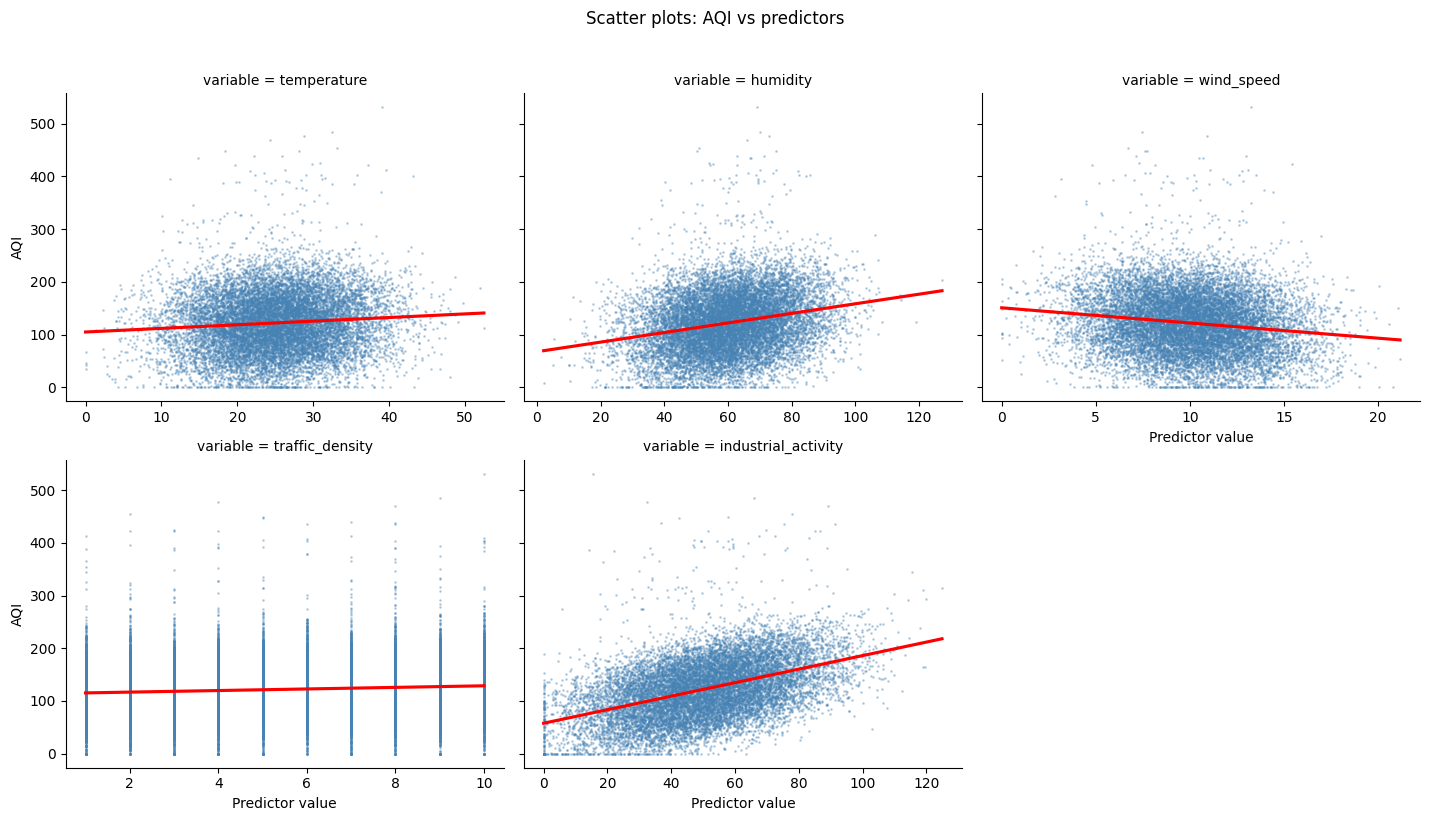

In [24]:
# Put data in long format: predictors + AQI
df_long = df.select_dtypes(include=[np.number]).melt(id_vars=["AQI"], var_name="variable", value_name="value")  # convert wide data to long form excluding AQI


# Scatter plots with regression lines, faceted by variable
g = sns.lmplot(
    data=df_long,
    x="value",
    y="AQI",
    col="variable",  # separate plot for each predictor
    col_wrap=3,  # ncol = 3
    sharex=False,  # scales = "free_x"
    scatter_kws={'alpha': 0.3, 's': 1, 'color': 'steelblue'},  # scatter plot of predictor vs AQI
    line_kws={'color': 'red'},  # add linear regression line without confidence band
    height=4,
    aspect=1.2,
    ci=None  # se = FALSE
)

g.set_axis_labels("Predictor value", "AQI")
g.fig.suptitle("Scatter plots: AQI vs predictors", y=1.02)
plt.tight_layout()
plt.show()

In [25]:
RQ1 = df.dropna()
RQ1.describe()

,temperature,humidity,wind_speed,traffic_density,industrial_activity,AQI
count,13139.000000,13139.000000,13139.000000,13139.000000,13139.000000,13139.000000
mean,25.001482,60.017756,9.992974,5.559327,50.236651,122.079301
std,7.023513,14.890612,3.018139,2.894324,20.066340,56.818610
min,0.000000,2.150000,0.000000,1.000000,0.000000,0.000000
25%,20.340000,49.765000,7.920000,3.000000,36.625000,82.670000
50%,24.960000,60.110000,9.980000,6.000000,50.450000,121.470000
75%,29.690000,70.120000,12.050000,8.000000,63.955000,159.410000
max,52.480000,127.190000,21.180000,10.000000,124.910000,531.030000


 For machine learning, we select particular variables of interest. This means that we remove the other variables
 that are not used as part of our regression formula.


Correlation exploration. This can also give information about multicollinearity between predictor variables.
 Predictor pairs should not have a correlation higher than an absolute of 0.7.

In [26]:
# 1. Select only the relevant numeric columns
cor_data = RQ1.select_dtypes(include=[np.number])

# 2. Remove rows with missing values (NA), because correlation cannot handle them
cor_data = cor_data.dropna()

# 3. Compute the correlation matrix
cor_matrix = cor_data.corr()

# 4. Print the correlation matrix in the console
cor_matrix

,temperature,humidity,wind_speed,traffic_density,industrial_activity,AQI
temperature,1.000000,-0.005800,-0.001615,0.003500,0.002204,0.082761
humidity,-0.005800,1.000000,0.004350,0.004136,0.004124,0.238186
wind_speed,-0.001615,0.004350,1.000000,0.000505,-0.005051,-0.154541
traffic_density,0.003500,0.004136,0.000505,1.000000,0.005147,0.074340
industrial_activity,0.002204,0.004124,-0.005051,0.005147,1.000000,0.453434
AQI,0.082761,0.238186,-0.154541,0.074340,0.453434,1.000000


Use correlation matrix to test linear relationship between variables.

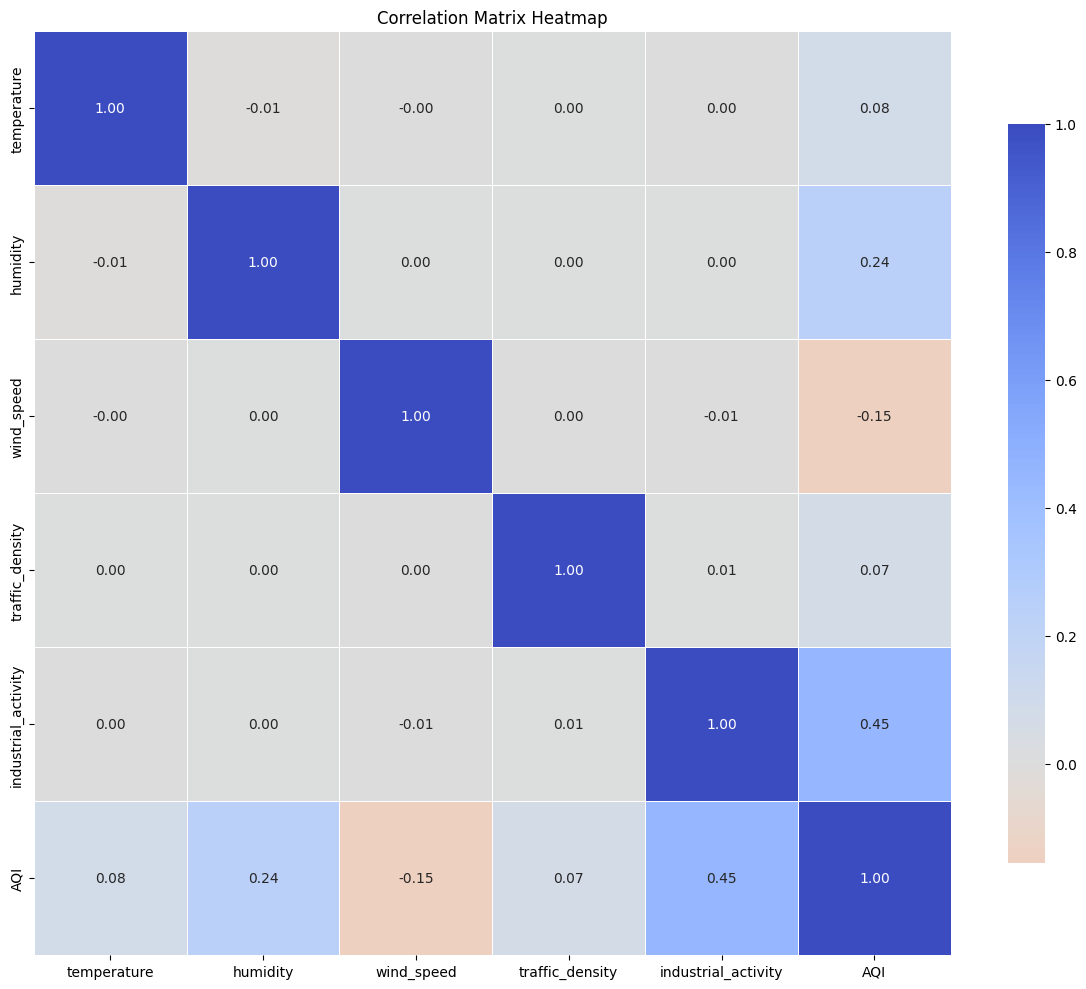

In [27]:
# 5. Visualize the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cor_matrix, annot=True, cmap='coolwarm_r', center=0,
            fmt='.2f', linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

Based on correlation and VIF, we don’t expect multi-collinearity.

## 4. Data analysis

**Task:** Regression

## 4.1 Test and training data

### Split dataset into training and testing data.

Typical splits are 80/20 or 70/30 splits.
 Training data are used to fit a model. Testing data are then used to test the model’s performance

In [28]:
# Train-test split (80% train, 20% test)
train_indices = np.random.choice(len(RQ1), size=int(0.8 * len(RQ1)), replace=False)
test_indices = np.setdiff1d(np.arange(len(RQ1)), train_indices)

data_train = RQ1.iloc[train_indices]
data_test = RQ1.iloc[test_indices]

In [29]:
# Separate features and target
X_train = data_train.drop('AQI', axis=1)
y_train = data_train['AQI']
X_test = data_test.drop('AQI', axis=1)
y_test = data_test['AQI']

 ## 4.2 Choose cross-validation.
Cross-validation is a resampling method to validate the fitted model during the training phase. It is also used to select hyperparameters to get the best performance.

In [30]:
# Define cross-validation method (5-fold)
cv = KFold(n_splits=5, shuffle=True, random_state=123)

# Standardize features (optional but often beneficial)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In 5-fold CV the training dataset is split into k=5 subsets (typically k = 5-10). Each fold is used once as validation data, while the remaining k-1 are used as training data to fit a model. By choosing CV the full model training process becomes more robust.

When combined with a training controller (e.g., trainControl in R’s caret package), multiple hyperparameter values are tested automatically, and the
best-performing set is selected based on cross-validation results. This removes the need for manual hyperparameter tuning.

## 4.3 Fit the models

Caret is a wrapper package that contains many different machine learning models. This makes comparison of
 different models easy. It is important to set a seed before fitting the model to ensure reproducibility.

 **Fit a linear regression model:** This model uses organic matter as the response (target) variable and the
 remaining variables as the predictor variables. A formula can be set manually, too, to select only particular
 variables.

In [31]:
# Linear Regression model (equivalent to glmStepAIC)
np.random.seed(123)
model_lm = LinearRegression()
lm_cv_scores = cross_val_score(model_lm, X_train_scaled, y_train, cv=cv, scoring='r2')
model_lm.fit(X_train_scaled, y_train)

LinearRegression()

In [32]:
print("Linear Regression Model:")
print(f"Cross-validation R² scores: {lm_cv_scores}")
print(f"Mean CV R²: {lm_cv_scores.mean():.4f}")
print(f"Test R²: {model_lm.score(X_test_scaled, y_test):.4f}")
print()

Linear Regression Model:
Cross-validation R² scores: [0.28709284 0.30124514 0.29536444 0.28492905 0.30773955]
Mean CV R²: 0.2953
Test R²: 0.3009



**Fit a decision tree model:** decision trees use an if-else structure to make predictions. The model can tend to
 overfitting.

In [33]:
# Decision Tree model
np.random.seed(123)

model_cart = DecisionTreeRegressor(
    random_state=123,
    max_depth=5,                    # Single parameter to control overfitting
    min_samples_leaf=3              # Basic leaf size control
)

cart_cv_scores = cross_val_score(model_cart, X_train, y_train, cv=cv, scoring='r2')
model_cart.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, min_samples_leaf=3, random_state=123)

In [34]:
print("Decision Tree Model:")
print(f"Cross-validation R² scores: {cart_cv_scores}")
print(f"Mean CV R²: {cart_cv_scores.mean():.4f}")
print(f"Test R²: {model_cart.score(X_test, y_test):.4f}")
print()

Decision Tree Model:
Cross-validation R² scores: [0.20825667 0.23934381 0.21555654 0.23614524 0.2399334 ]
Mean CV R²: 0.2278
Test R²: 0.2522



**Fit a random forest model:** makes use of several decision trees and averages the predictions among multiple
 trees. Typically, using a model that combines several trees ((ensemble models) makes more robust and better
 predictions than a single tree.

In [35]:
# Random Forest model
np.random.seed(123)
model_rf = RandomForestRegressor(random_state=123)
rf_cv_scores = cross_val_score(model_rf, X_train, y_train, cv=cv, scoring='r2')
model_rf.fit(X_train, y_train)

RandomForestRegressor(random_state=123)

In [36]:
print("Random Forest Model:")
print(f"Cross-validation R² scores: {rf_cv_scores}")
print(f"Mean CV R²: {rf_cv_scores.mean():.4f}")
print(f"Test R²: {model_rf.score(X_test, y_test):.4f}")
print()

Random Forest Model:
Cross-validation R² scores: [0.22311446 0.25368456 0.24563633 0.24692319 0.24634861]
Mean CV R²: 0.2431
Test R²: 0.2465



 **Fit a gradient boosting model:** this model also uses several trees. However, it starts with a single tree and
 improves this tree’s performance several times by reducing its error rate sequentially.

In [37]:
# Gradient Boosting model
np.random.seed(123)
model_gbm = GradientBoostingRegressor(
    n_estimators=500,  # equivalent to n.trees=500
    learning_rate=0.1,  # equivalent to shrinkage=0.1
    max_depth=3,  # equivalent to interaction.depth=3
    min_samples_leaf=10,  # equivalent to n.minobsinnode=10
    random_state=123
)
gbm_cv_scores = cross_val_score(model_gbm, X_train, y_train, cv=cv, scoring='r2')
model_gbm.fit(X_train, y_train)


GradientBoostingRegressor(min_samples_leaf=10, n_estimators=500,
                          random_state=123)

In [38]:
print("Gradient Boosting Model:")
print(f"Cross-validation R² scores: {gbm_cv_scores}")
print(f"Mean CV R²: {gbm_cv_scores.mean():.4f}")
print(f"Test R²: {model_gbm.score(X_test, y_test):.4f}")
print()

Gradient Boosting Model:
Cross-validation R² scores: [0.24876332 0.26947999 0.26873859 0.26340854 0.27299053]
Mean CV R²: 0.2647
Test R²: 0.2743



In [ ]:
#param_grid = {
#     'n_estimators': [500, 1000, 2000, 2500],
#     'max_depth': [3, 6, 12, 15],
#     'learning_rate': [0.1],
#     'min_samples_leaf': [10]}
#grid_search = GridSearchCV(GradientBoostingRegressor(random_state=123),
#                           param_grid, cv=cv, scoring='r2')
#grid_search.fit(X_train, y_train)
#model_gbm = grid_search.best_estimator_

 Now, we are done training the models. In the next step, we test the model performance using the test dataset

## Test the model performance

 In this step, we make use of the finished models to make predictions with the test dataset.

In [39]:
# Predictions for each model
pred_lm = LinearRegression().fit(X_train, y_train).predict(X_test)
pred_cart = DecisionTreeRegressor().fit(X_train, y_train).predict(X_test)
pred_rf = RandomForestRegressor().fit(X_train, y_train).predict(X_test)
pred_gbm = model_gbm.predict(X_test)

We compare the relationship between the observations and the predictions of the test data. One popular
 measure is the R-squared value. It explains the proportion of variance in the response variable that is
 explained by using the predictor variables.

 One easy way to compute this measure is to use the squared correlation coefficient.

In [40]:
# Calculate R² for each model
r2_lm = round(r2_score(y_test, pred_lm), 4)
r2_cart = round(r2_score(y_test, pred_cart), 4)
r2_rf = round(r2_score(y_test, pred_rf), 4)
r2_gbm = round(r2_score(y_test, pred_gbm), 4)

print(f"R² for Linear Model: {r2_lm}")
print(f"R² for CART: {r2_cart}")
print(f"R² for Random Forest: {r2_rf}")
print(f"R² for Gradient Boosting: {r2_gbm}")

R² for Linear Model: 0.3009
R² for CART: -0.4077
R² for Random Forest: 0.2463
R² for Gradient Boosting: 0.2743


We can compare the performance of the different models by showing a table with r-squared values or we can also show it visually.

In [41]:
# Create DataFrame with R² values and algorithms
r2 = pd.DataFrame({
    "r2": [r2_lm, - r2_cart, r2_rf, r2_gbm],
    "algorithm": pd.Categorical(
        ["Linear model", "Decision Tree", "Random Forests", "Gradient Boosting"],
        categories=["Linear model", "Decision Tree", "Random Forests", "Gradient Boosting"],
        ordered=True
    )
})

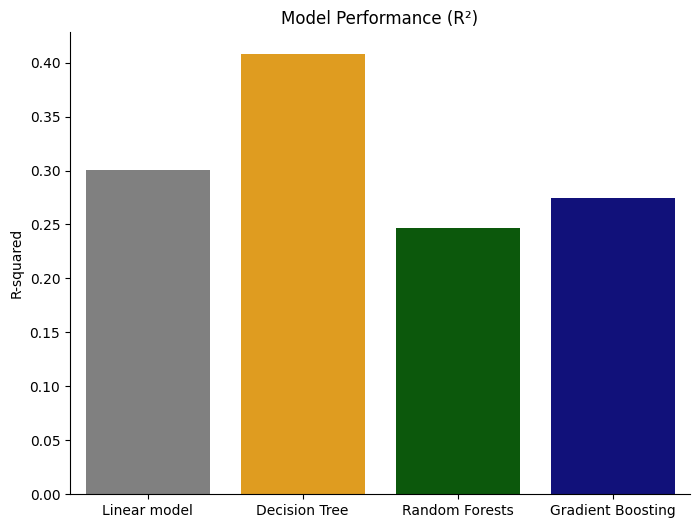

In [42]:
# Plot
plt.figure(figsize=(8, 6))
sns.barplot(data=r2, x="algorithm", y="r2", hue="algorithm",
            palette={"Linear model": "grey",
                     "Decision Tree": "orange",
                     "Random Forests": "darkgreen",
                     "Gradient Boosting": "darkblue"})

plt.ylabel("R-squared")
plt.xlabel("")
plt.title("Model Performance (R²)")
plt.legend([],[], frameon=False)  # remove legend
sns.despine()
plt.show()

 Now we are done with testing the model performance, however we have no idea about how the fitted model
 actually looks like. E.g., what variables are important and in what relationship is a predictive variable with the
 response variable. Furthermore, we might have some errors in our models because of a wrong data
 preparation or variable use.
 To get information about the Fiddler models, we can make use of interpretable machine learning tools

To get information about the Fiddler models, we can make use of interpretable machine learning tools.

## 5 Interpretable machine learning

### 5.1 Variable importance

There are several interpretable machine learning tools available. A popular method is the variable importance method. There are several ways to get a variable importance. In this guide, we use the permutation variable importance. Computation takes some minutes.

Permutation importance works by **randomly permuting** the values of each feature and observing how much the model’s predictive performance declines. If shuffling a feature leads to a large decrease in performance, the feature is considered important.

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

def plot_perm_boxplots(
    model,
    X,
    y,
    feature_names,
    n_repeats=30,
    scoring="r2",
    title="Linear model",
    top_n=15,
    random_state=123,
):
    """
    Boxplots de Permutation Feature Importance para un modelo sklearn ya entrenado.
    - model: estimador ya .fit(...)
    - X, y: datos sobre los que evaluar la importancia (mejor: set de test)
    - feature_names: lista con los nombres de las columnas en el mismo orden que X
    - scoring: métrica (p.ej. 'r2' para regresión, 'accuracy' si fuera clasificación)
    - top_n: cuántas features mostrar (ordenadas por importancia media)
    """
    r = permutation_importance(
        model, X, y, n_repeats=n_repeats,
        random_state=random_state, scoring=scoring, n_jobs=-1
    )

    order = np.argsort(r.importances_mean)[::-1]
    imp = r.importances[order]              # shape: (n_repeats, n_features)
    names = np.array(feature_names)[order]

    top_n = min(top_n, imp.shape[0])        # recorta a top_n
    imp = imp[:top_n, :]
    names = names[:top_n]

    plt.figure(figsize=(7, 0.45*top_n + 2))
    plt.boxplot(imp.T, vert=False, labels=names, whis=1.5, showfliers=True)
    plt.title(title)
    plt.xlabel("Importance")
    plt.grid(True, axis="x", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()


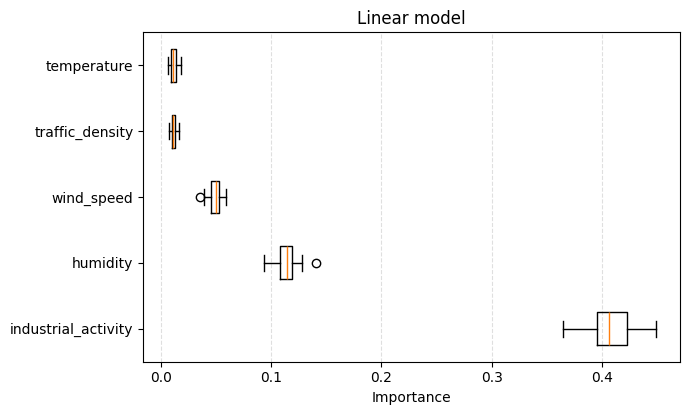

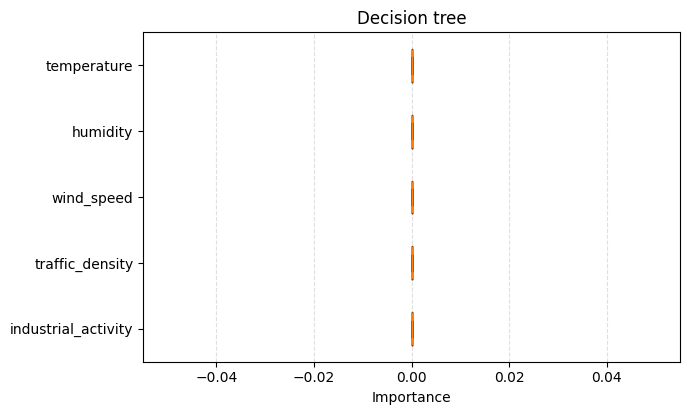

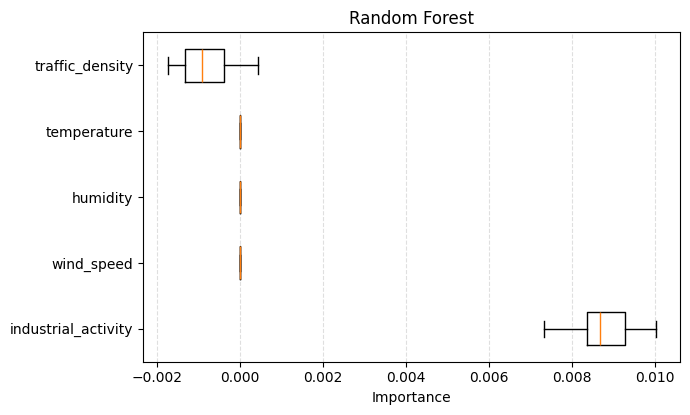

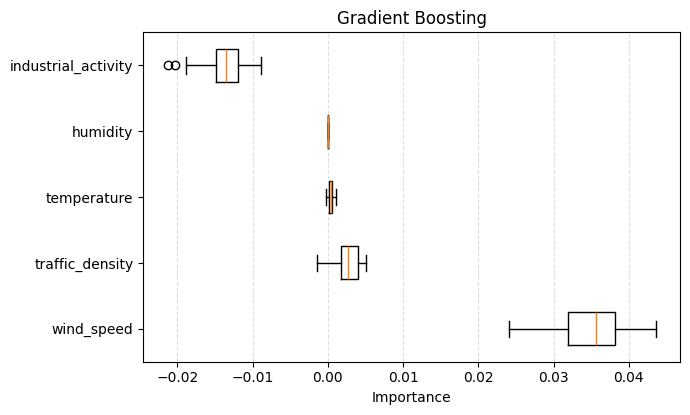

In [48]:
# Nombres de columnas (en el mismo orden que usaste para escalar)
feature_names = X_train.columns.tolist()

# Importancia por permutación sobre el set de test
plot_perm_boxplots(
    model_lm,
    X_test_scaled,
    y_test,
    feature_names=feature_names,
    n_repeats=30,
    scoring="r2",
    title="Linear model",
    top_n=12
)
plot_perm_boxplots(
    model_cart,
    X_test_scaled,
    y_test,
    feature_names=feature_names,
    n_repeats=30,
    scoring="r2",
    title="Decision tree",
    top_n=12
)
plot_perm_boxplots(
    model_rf,
    X_test_scaled,
    y_test,
    feature_names=feature_names,
    n_repeats=30,
    scoring="r2",
    title="Random Forest",
    top_n=12
)
plot_perm_boxplots(
    model_gbm ,
    X_test_scaled,
    y_test,
    feature_names=feature_names,
    n_repeats=30,
    scoring="r2",
    title="Gradient Boosting",
    top_n=12
)


## 5.1 Variable associations

Another popular model intepretation method is the partial dependence plot. It gives information about a how a predictor variable and the predicted
response variable are linked to each other.

## 5.3 Variable interactions

Domain knowledge about air quality may suggests a few plausible interactions:
* **Industrial activity × Humidity:** High humidity can trap particulate matter and slow dispersion, so the effect of industrial emissions may
depend on ambient moisture.
* **Industrial activity × Wind speed:** Increased wind can disperse pollutants, so emissions might be less impactful when winds are strong.
* **Humidity × Temperature:** Temperature and humidity together influence chemical reactions that create secondary pollutants like ozone.

We can use 2-Way interaction PDPs to detect variable interaction effects. For this exploration, we select gradient boosting model, because it
ranked high in the performance metric and allows to detect non-linear interaction effects.

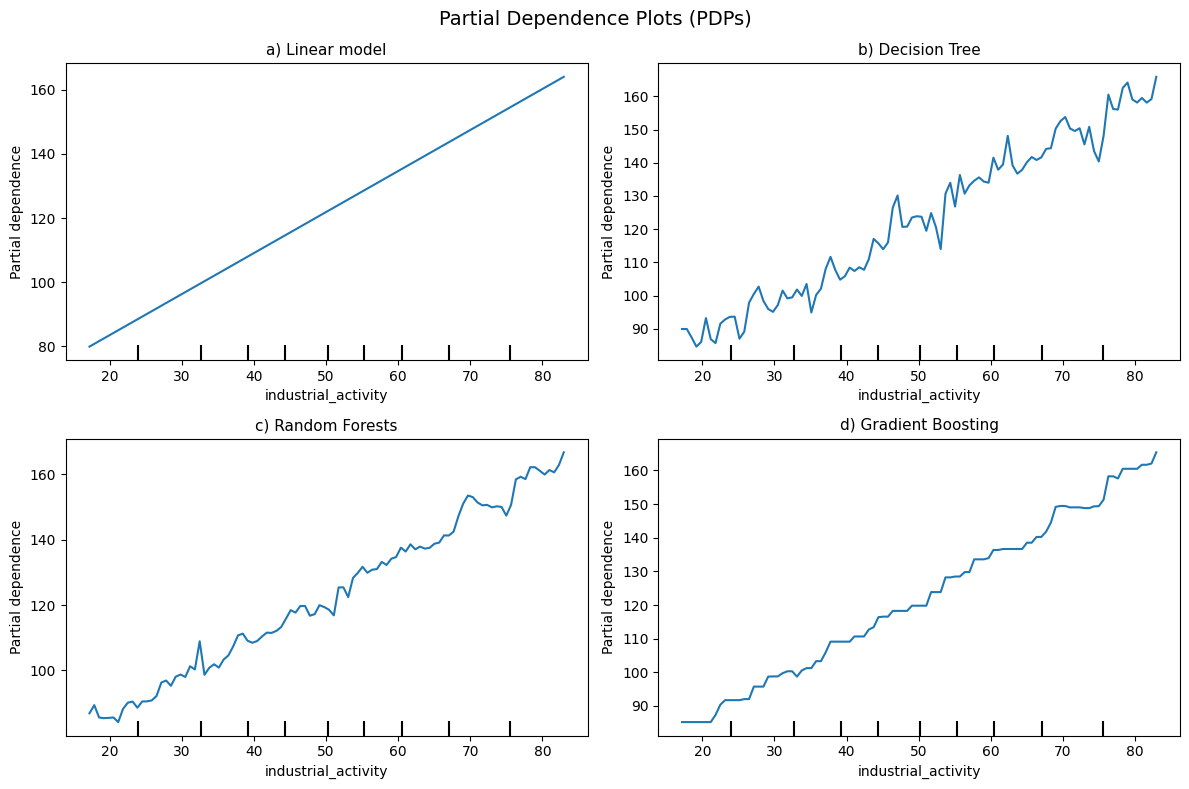

In [56]:
# --- Instalaciones (si estás en Colab y te faltan paquetes) ---
# !pip install -q scikit-learn pandas matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import PartialDependenceDisplay


feature = "industrial_activity"


num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()


assert feature in X_train.columns, f"La columna '{feature}' no está en X_train.columns"

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop",
)

# 3) Definir modelos (regresión para AQI)
models = {
    "a) Linear model": Pipeline([("prep", preprocess),
                                 ("model", LinearRegression())]),
    "b) Decision Tree": Pipeline([("prep", preprocess),
                                  ("model", DecisionTreeRegressor(random_state=123))]),
    "c) Random Forests": Pipeline([("prep", preprocess),
                                   ("model", RandomForestRegressor(
                                       n_estimators=500, random_state=123, n_jobs=-1))]),
    "d) Gradient Boosting": Pipeline([("prep", preprocess),
                                      ("model", GradientBoostingRegressor(random_state=123))]),
}

# 4) Entrenar y graficar PDPs en un panel 2x2
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, (title, pipe) in zip(axes, models.items()):
    # Entrenar
    pipe.fit(X_train, y_train)

    # PDP (con eje X en unidades originales, gracias al pipeline)
    PartialDependenceDisplay.from_estimator(
        estimator=pipe,
        X=X_test,                       # usa el set de test SIN escalar
        features=[feature],             # nombre de la variable original
        kind="average",
        grid_resolution=100,
        ax=ax,
    )
    ax.set_title(title, fontsize=11)
    ax.set_ylabel("Predicted AQI")

fig.suptitle("Partial Dependence Plots (PDPs)", fontsize=14)
plt.tight_layout()
plt.show()



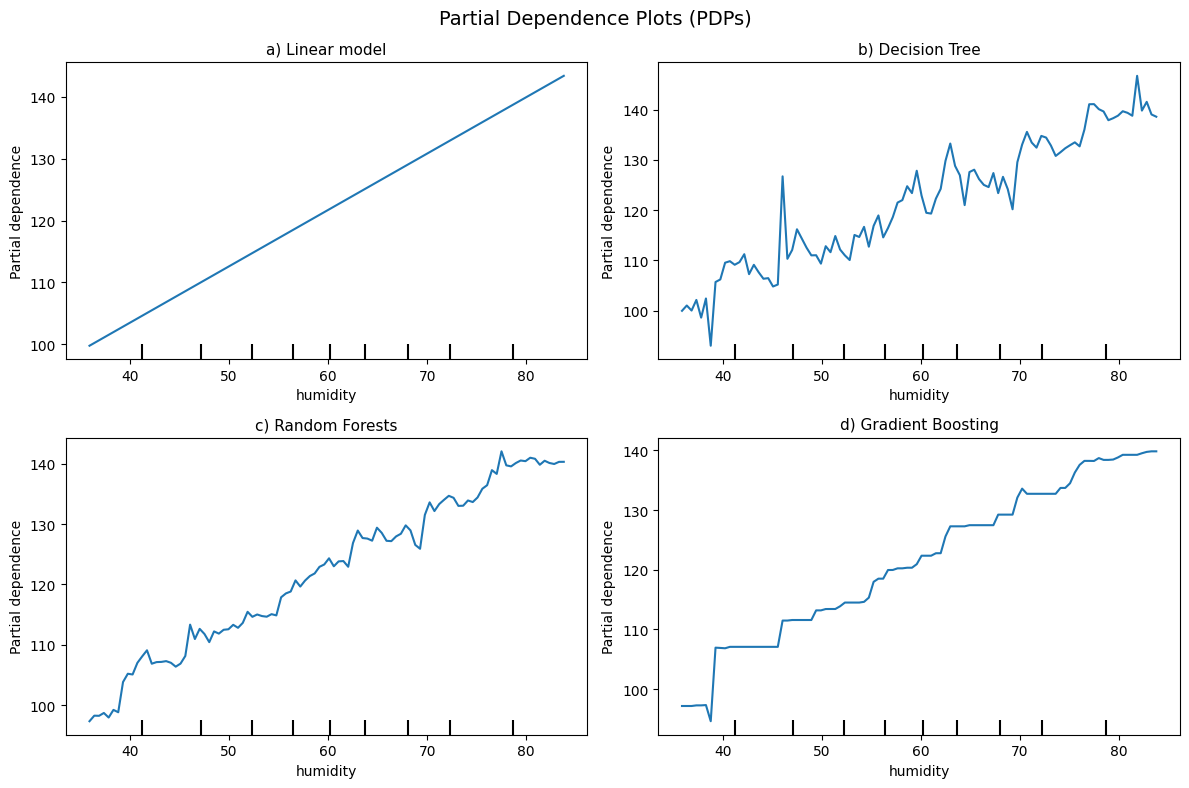

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import PartialDependenceDisplay


feature = "humidity"


num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()


assert feature in X_train.columns, f"La columna '{feature}' no está en X_train.columns"

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop",
)

# 3) Definir modelos (regresión para AQI)
models = {
    "a) Linear model": Pipeline([("prep", preprocess),
                                 ("model", LinearRegression())]),
    "b) Decision Tree": Pipeline([("prep", preprocess),
                                  ("model", DecisionTreeRegressor(random_state=123))]),
    "c) Random Forests": Pipeline([("prep", preprocess),
                                   ("model", RandomForestRegressor(
                                       n_estimators=500, random_state=123, n_jobs=-1))]),
    "d) Gradient Boosting": Pipeline([("prep", preprocess),
                                      ("model", GradientBoostingRegressor(random_state=123))]),
}

# 4) Entrenar y graficar PDPs en un panel 2x2
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, (title, pipe) in zip(axes, models.items()):
    # Entrenar
    pipe.fit(X_train, y_train)

    # PDP (con eje X en unidades originales, gracias al pipeline)
    PartialDependenceDisplay.from_estimator(
        estimator=pipe,
        X=X_test,                       # usa el set de test SIN escalar
        features=[feature],             # nombre de la variable original
        kind="average",
        grid_resolution=100,
        ax=ax,
    )
    ax.set_title(title, fontsize=11)
    ax.set_ylabel("Predicted AQI")

fig.suptitle("Partial Dependence Plots (PDPs)", fontsize=14)
plt.tight_layout()
plt.show()



5.3 Variable interactions

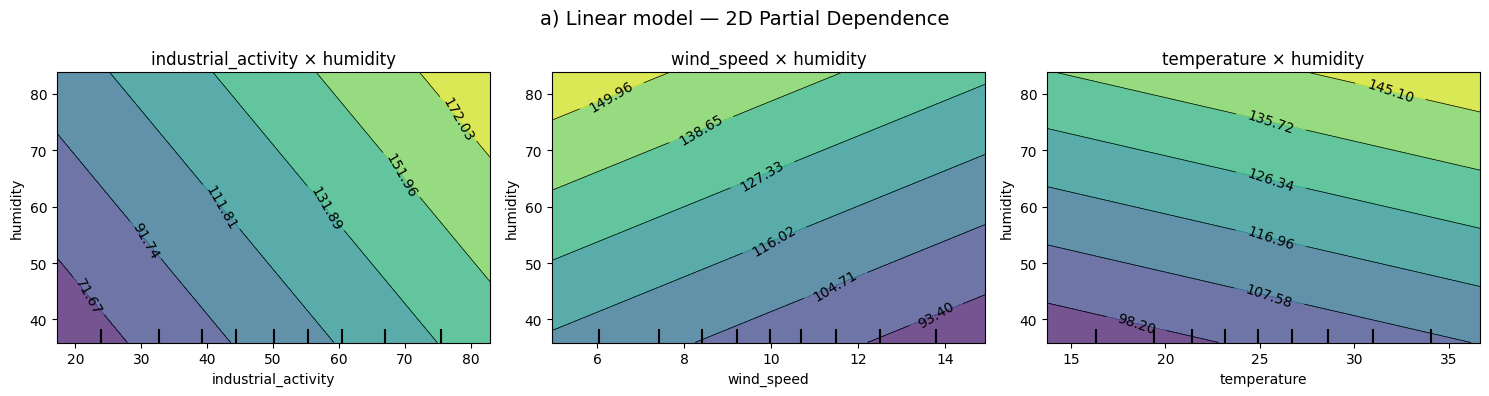

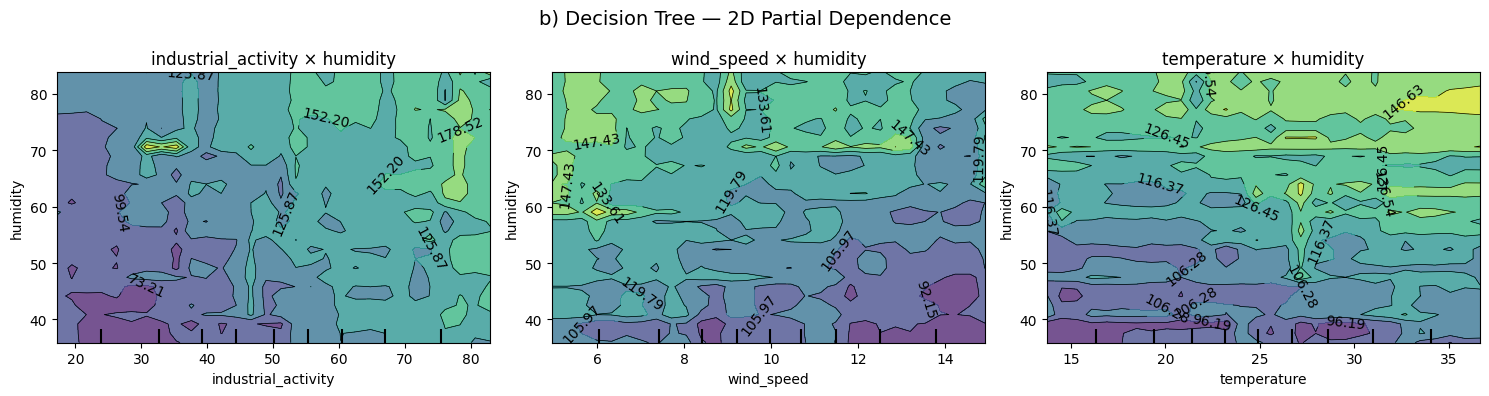

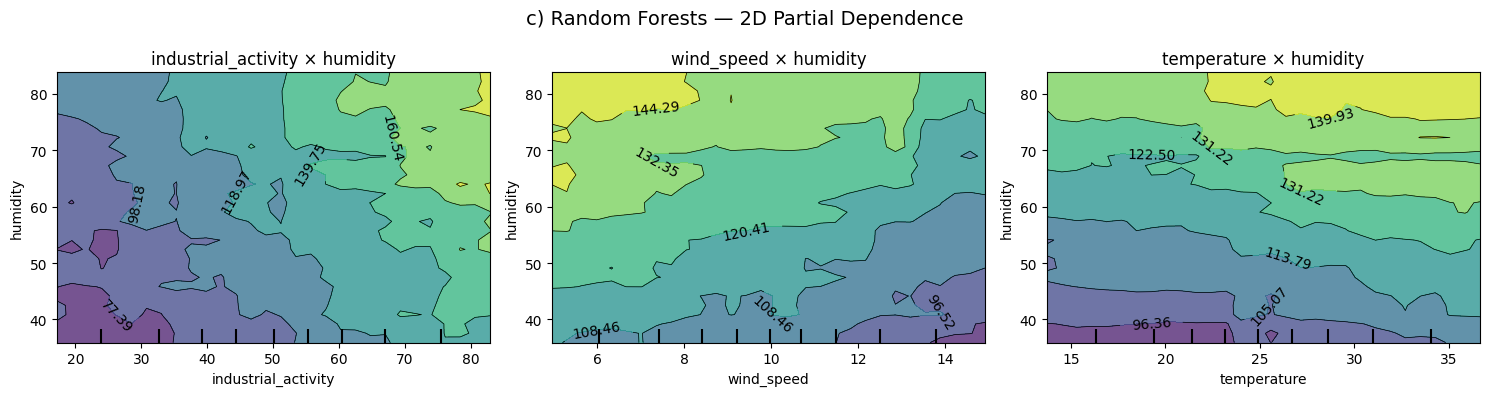

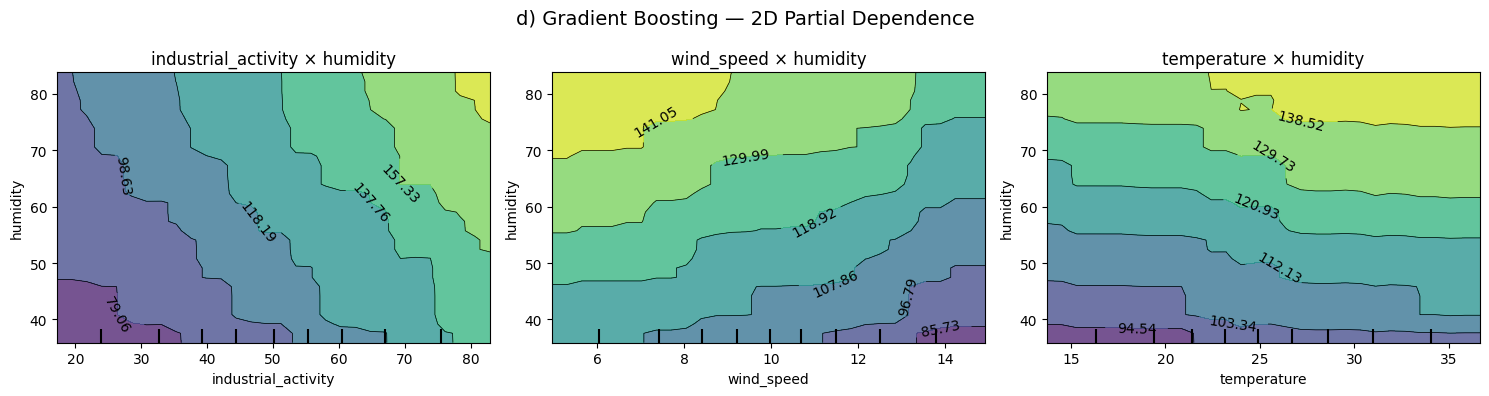

In [61]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

pairs = [
    ("industrial_activity", "humidity"),
    ("wind_speed", "humidity"),
    ("temperature", "humidity"),
]

# Verificación rápida
for f1, f2 in pairs:
    assert f1 in X_train.columns, f"'{f1}' no está en X_train.columns"
    assert f2 in X_train.columns, f"'{f2}' no está en X_train.columns"

#
for name, pipe in models.items():
    pipe.fit(X_train, y_train)

#
for name, pipe in models.items():
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes = axes.ravel()

    for ax, pair in zip(axes, pairs):
        PartialDependenceDisplay.from_estimator(
            estimator=pipe,
            X=X_test,                  #
            features=[pair],           #
            kind="average",
            grid_resolution=30,
            ax=ax,
        )
        ax.set_title(f"{pair[0]} × {pair[1]}")
    fig.suptitle(f"{name} — 2D Partial Dependence", fontsize=14)
    plt.tight_layout()
    plt.show()

